In [38]:
import numpy as np
import pandas as pd
import ast

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import confusion_matrix

from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
import seaborn as sns

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Set random seed for reproducibility
np.random.seed(42)

# Colormaps that support higher numbers of categories
import colorcet as cc


# Loading Data

In [2]:
# df = pd.read_pickle("data/df_train.pkl") # original load path. Should probably change back to this for submission. 


df = pd.read_pickle("../../../data/df_train.pkl")

# Added stratify to ensure the class distribution is the same in the train and test split
df_train, df_val = train_test_split(df, test_size=0.1, random_state=42, stratify=df["industry"])

In [3]:
# Convert string embeddings to list inplace, then create numpy arrays
df_train["business_description_embedding"] = df_train["business_description_embedding"].apply(ast.literal_eval)
df_val["business_description_embedding"] = df_val["business_description_embedding"].apply(ast.literal_eval)

X_train = np.array(df_train["business_description_embedding"].tolist())
X_val = np.array(df_val["business_description_embedding"].tolist())

In [4]:
df_train.head(3)

,id,industry,business_description_embedding
37424,41312,Capital Goods,"[0.002649254, -0.03847494, -0.027260592, 0.020..."
9085,9913,Materials,"[-0.019461915, 0.0002782993, -0.026645942, 0.0..."
15837,17277,Materials,"[0.061642032, -0.058342014, -0.031209921, -0.0..."


# Transforming Data (Label Encoding)

### Tasks:
- Use the scikit-learn label encoder to encode the industry names
- Check if all classes contained in the validation set are also in the training set

#

Fitting The LabelEncoder on the industry names

In [5]:
# Fit the label encoder to the classes (industry names)
label_encoder =  LabelEncoder().fit(df_train.industry)

Check if the classes contained in the validation set are also in the training set. This is important, since a model wont be able to predict for unseen classes. 

In [6]:
print(f"Train count {len(df_train.industry.unique())} Val count {len(df_val.industry.unique())}")
if all(val_label in df_val.industry.unique() for val_label in df_train.industry.unique()):
    print("All val labels are also in train set")
else:
    print("Val does NOT contain the same labels as the train set")

Train count 25 Val count 25
All val labels are also in train set


Encode the train and val labels. This encodes the industry labels with a numerical value.

In [7]:
y_train = label_encoder.transform(df_train.industry)
y_val =  label_encoder.transform(df_val.industry)
y_train

array([ 2, 15, 15, ..., 11, 15, 23], shape=(28535,))

# Visualize the data

### Tasks:
- Are certain classes over- or under represented? Either produce a table or a plot to show this.
- Inspect whether there is signal in the business description embeddings:
    - Perform a PCA to project data into 2 dimensions
    - Plot projected data in Scatterplot and color based on classes
    - Provide a description of what you see and judge whether there is signal in the data that allows industry classification

Important: Ensure that your plots have proper axis descriptions and titles. Style the plots so that differences in class distributions are visible (e.g. scatter size, transparency, color, etc.)

### Class distribution

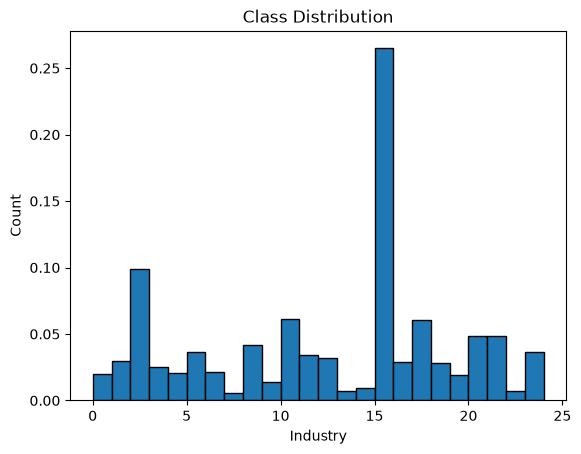

Counts per class:


industry
Materials                                         7555
Capital Goods                                     2814
Financial Services                                1742
Pharmaceuticals, Biotechnology & Life Sciences    1732
Technology Hardware & Equipment                   1392
Software & Services                               1383
Energy                                            1193
Consumer Durables & Apparel                       1048
Food, Beverage & Tobacco                           985
Health Care Equipment & Services                   913
Banks                                              853
Media & Entertainment                              824
Real Estate Management & Development               815
Commercial & Professional Services                 724
Consumer Services                                  605
Consumer Discretionary Distribution & Retail       592
Automobiles & Components                           563
Semiconductors & Semiconductor Equipment           546
T

In [ ]:
# Plot the class distribution or provide a table that shows how many times each class (industry) appears
# Describe your findings
n_industries = len(np.unique(y_train))
plt.hist(y_train, bins=range(n_industries), edgecolor="black", density=True)
plt.title("Class Distribution")
plt.xlabel("Industry")
plt.ylabel("Count")
plt.show()

print("Counts per class:")
df_train.industry.value_counts()

There are some industries like "materials" and "capital goods" that contain a lot more samples than others. Then there is a large middle section of industries with 500 to 1000  samples and at the end is a small numbe rof industries who have fewer than 500 samples.

Because a quarter of the samples is of the industry "materials", a naive classifier that only predicts that class can already reach an accuracy of ca. ~25%. 

To make sure that the classifier learns to predict the right class and not only that this is the majority class, we need to account for this.

This could be done through adjusting the loss function or using a classifier that can inversely weight the samples by the class"s frequency.

A different approach would be to use a technique like SMOTE, or reducing the number of samples in the majority class to make it more equal. Although i think that we do want to use all the samples that we have.

Regarding if these numbers make sense. I am not 100% sure, but I think they look mostly sensible. Though since there appears to be some overlap between industries the classification could change depending on what the company views itself as, this nuance could be hard for our classifier to detect.

### PCA - Dimensionality reduction and visualization

Projected data from (28535, 768) to (28535, 2)


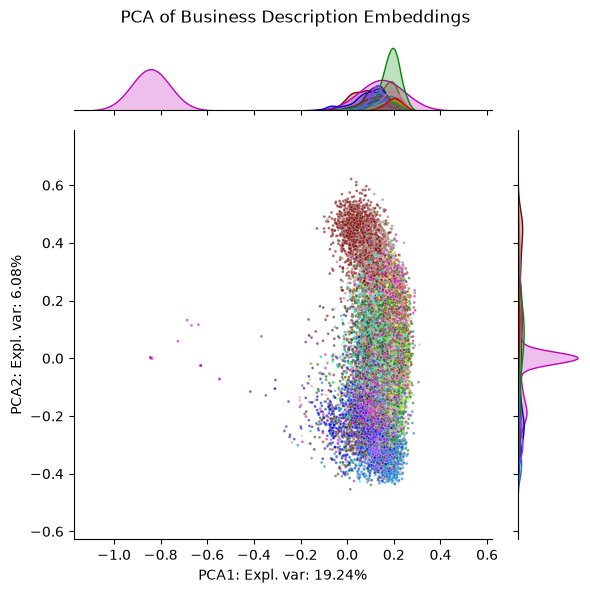

In [9]:
from seaborn.axisgrid import JointGrid
# Performa a PCA and plot the projected data. Color the scatter plot based on the classes
# Analyse what you see

# PCA 
pca_decomp = PCA(n_components=2).fit(X_train)
pca = pca_decomp.transform(X_train)
print(f"Projected data from {X_train.shape} to {pca.shape}")

# Create colormap with as many colors as there are industries
n_industries = len(np.unique(y_train))
industry_cmap = ListedColormap(cc.glasbey[:n_industries])

# Plot the first two principal components
g = sns.jointplot(x=pca[:, 0], y=pca[:, 1], hue=y_train, palette=industry_cmap, s= 4, alpha=0.6, legend=False)
#set title
g.figure.suptitle("PCA of Business Description Embeddings")
g.figure.tight_layout()
g.set_axis_labels(f"PCA1: Expl. var: {pca_decomp.explained_variance_ratio_[0] * 100:.2f}%", f"PCA2: Expl. var: {pca_decomp.explained_variance_ratio_[1] * 100:.2f}%")
plt.show()


A significant part of the distributions is centered on these outliers. But there is a second peak in PCA1 where all the other points also are. It seems like a few points there are distorting everything. These points are part of a larger group though.

It looks like there are potential outliers in the dataset or something else that distorts the result, since there are almost no points on the left side of the plot. But something needs to be there if PCA decided that that direction is most valuable to keep. 

Otherwise the data looks to be somewhat separable, although there is some overlap between classes and some are more clearly defined than others.

We will try to investigate this result further and find the reason for this distorted plot. 

It is suspected that there are a lot of very simmilar or even duplicate samples on the left side since if there were really only these ~10 points in that area, that would not be enough to distort the plot like this. 

To investigate this we look at the embeddings of the business descriptionsm, duplicates and other dimensions of the pca to see if the other dimensions look better

In [10]:
def plot_explore_pca(X_data, y_data, first_n_components = 5, title = "PCA of Business Description Embeddings in multiple pca dimensions"):
    # Get PCA of the reduced dataset
    pca_decomp = PCA(n_components=first_n_components).fit(X_data)
    pca = pca_decomp.transform(X_data)

    fig, axes = plt.subplots(first_n_components, first_n_components, figsize=(16, 16))
    plt.suptitle(title)

    for i in range(first_n_components):
        for j in range(first_n_components):
            if i == j:
                axes[i, j].set_xticks([])
                axes[i, j].set_yticks([])   
                continue

            sns.scatterplot(x=pca[:, i], y=pca[:, j], hue=y_data, palette=industry_cmap, s= 4, alpha= 0.6, ax=axes[i, j], legend=False)
            axes[i, j].set_xlabel(f"PCA{i+1}: Expl. var: {pca_decomp.explained_variance_ratio_[i] * 100:.2f}%")
            axes[i, j].set_ylabel(f"PCA{j+1}: Expl. var: {pca_decomp.explained_variance_ratio_[j] * 100:.2f}%")
            axes[i, j].set_xticks([])
            axes[i, j].set_yticks([])  
 
    plt.tight_layout()
    plt.show()

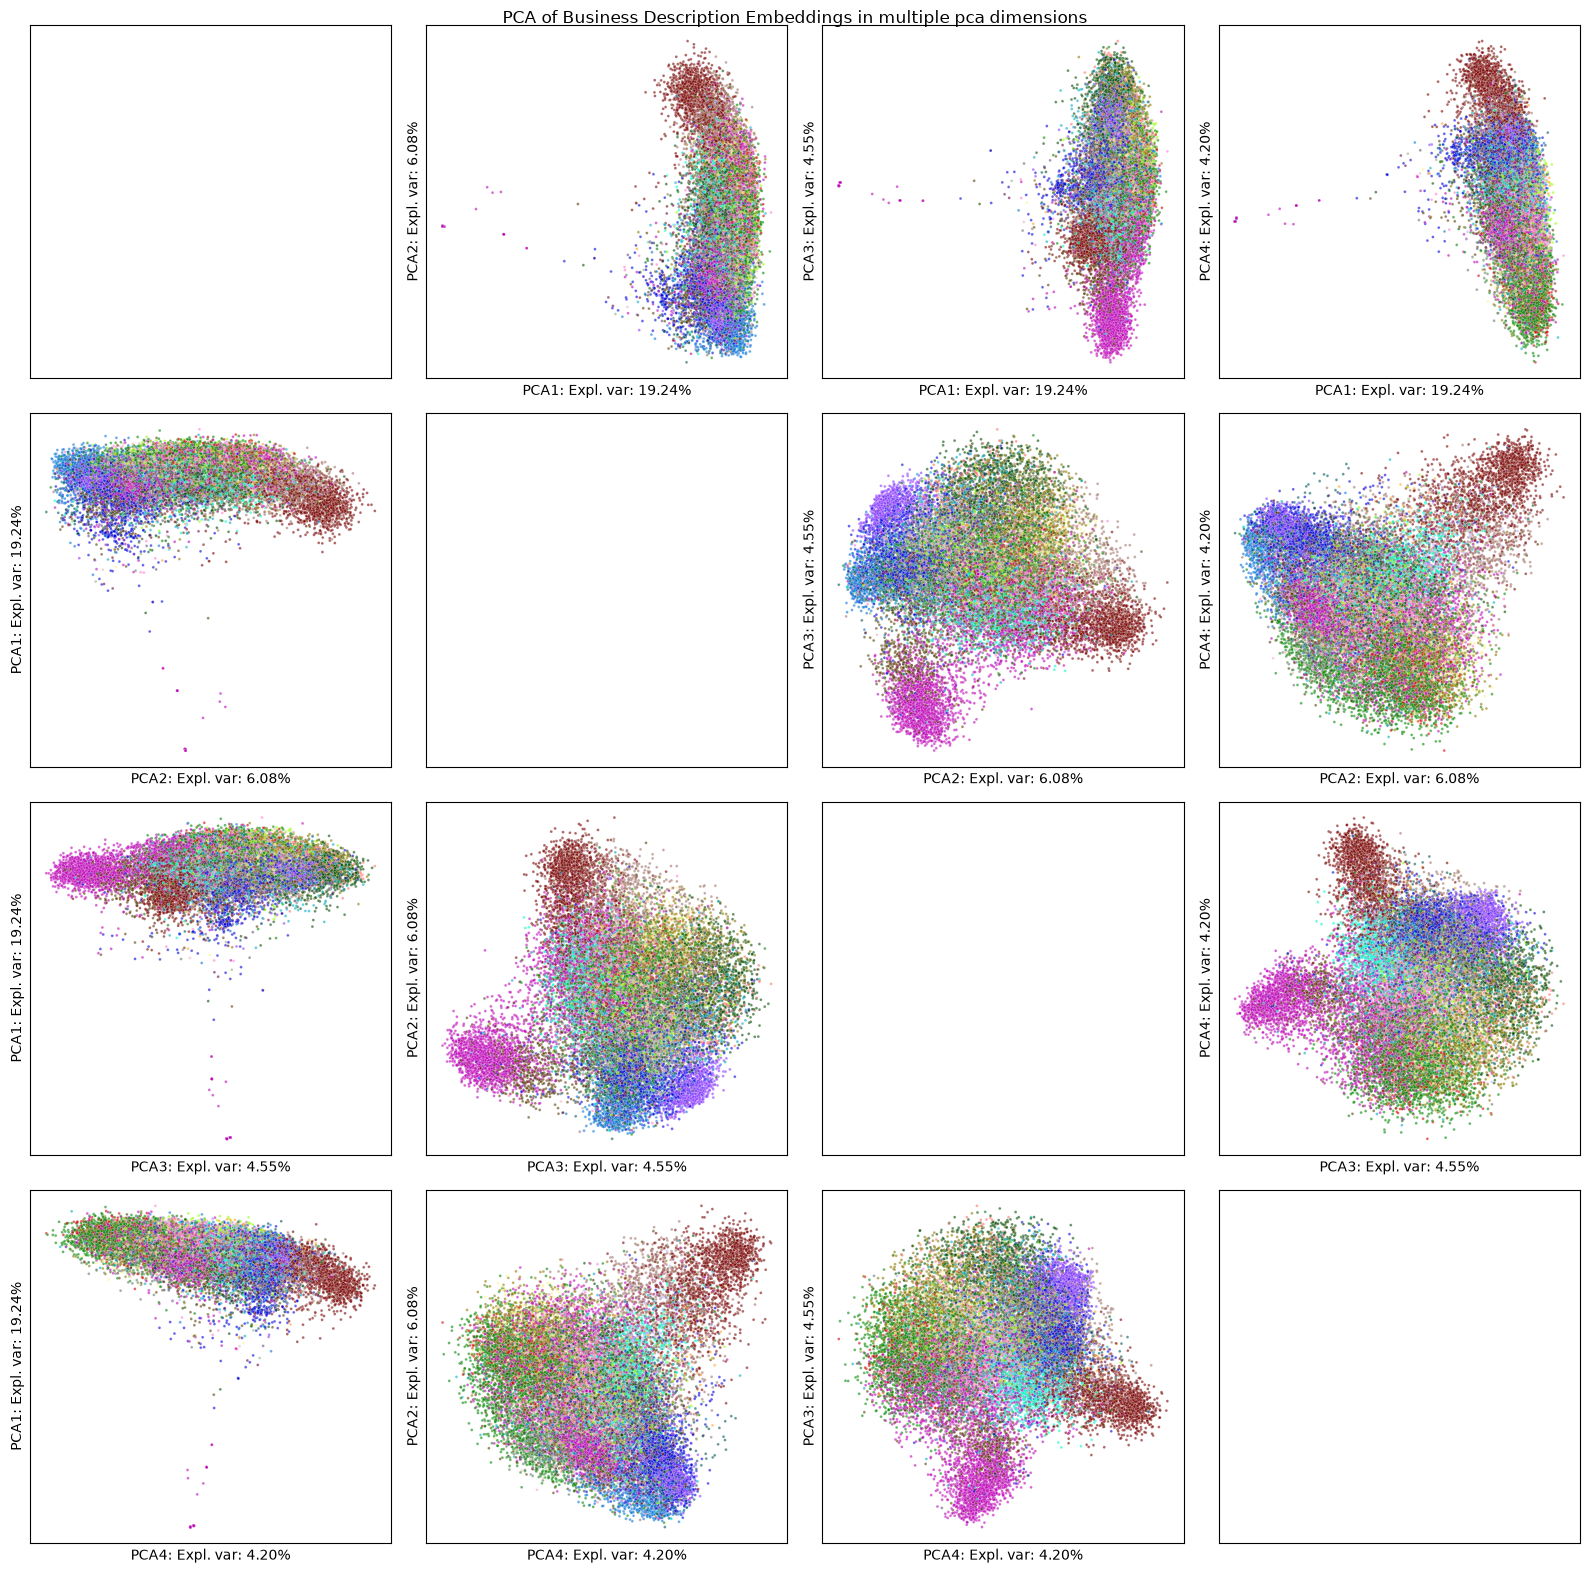

In [11]:
plot_explore_pca(X_train,y_train, first_n_components=4)

Plots containing PCA 1 are distored by some outliers. The other components look fine

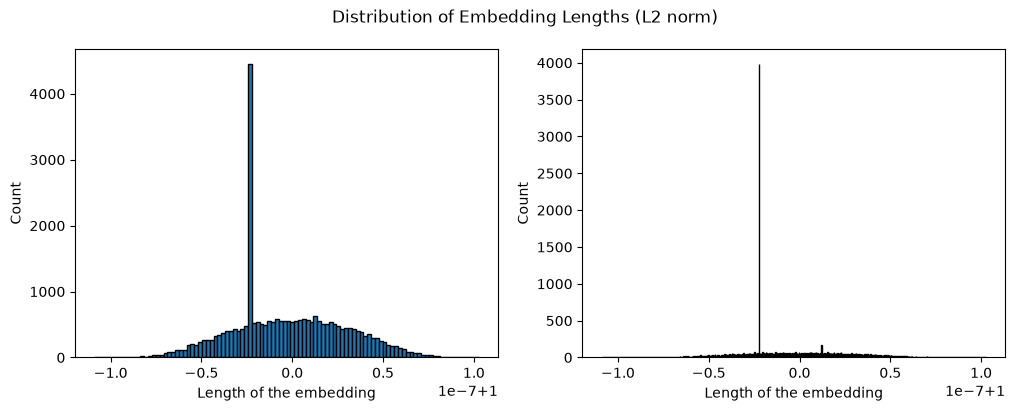

Min length:  0.9999998910388799
Max length:  1.0000001026570713


In [ ]:
# Distribution of the length || x_i ||² of the business description embeddings
# If there are a lot of duplicates or near duplicates we should be able to observe that
# The plots show "negative" because it is in scientific notation. 1e-7+1 shifts it to the right.
def plot_embedding_length_distribution(embeddings: np.ndarray, title = "Distribution of Embedding Lengths (L2 norm)"):

    l2_lengths = np.linalg.norm(embeddings, axis=1, ord=2)


    plt.figure(figsize=(12, 4))
    plt.suptitle(title)

    plt.subplot(1, 2, 1)
    plt.hist(l2_lengths, bins=100, edgecolor="black")
    plt.xlabel("Length of the embedding")
    plt.ylabel("Count")

    plt.subplot(1, 2, 2)
    plt.hist(l2_lengths, bins=1000, edgecolor="black")
    plt.xlabel("Length of the embedding")
    plt.ylabel("Count")
    
    plt.show()

    print("Min length: ", np.min(l2_lengths))
    print("Max length: ", np.max(l2_lengths))

plot_embedding_length_distribution(X_train)

There are a lot of duplicates or near-duplicates in the data. There is one high spike of approximately 4000 samples that are very close together (or are just the same distance from the origin).

Since they are exactly this is likely an error in the data and we should remove them. They wont give the model a good learning signal. 

We"ll look at the distribution of Embedding Lengths and the PCA"s again to see if it looks better.

Number of exact duplicate embeddings: 0
Number of exact duplicate embeddings: 0


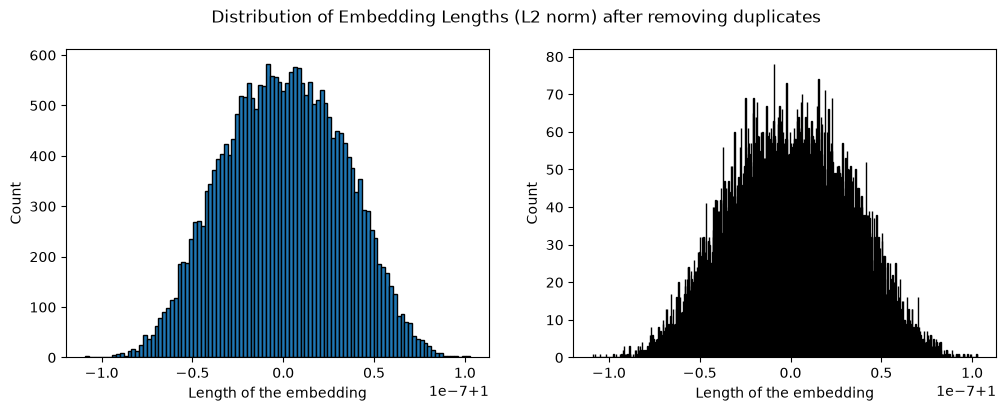

Min length:  0.9999998910388799
Max length:  1.0000001026570713


In [ ]:
def remove_duplicates(df):
    # Count exact duplicates
    exact_duplicates = df.business_description_embedding.duplicated().sum()
    print(f"Number of exact duplicate embeddings: {exact_duplicates}")

    df = df.drop_duplicates(subset=["business_description_embedding"])
    return df

df_train = remove_duplicates(df_train)

# Create embeddins and labels for this reduced dataset
X_train = np.array(df_train["business_description_embedding"].tolist())
y_train = label_encoder.transform(df_train.industry)


# val set
df_val = remove_duplicates(df_val)  
X_val = np.array(df_val["business_description_embedding"].tolist())
y_val = label_encoder.transform(df_val.industry)

plot_embedding_length_distribution(X_train, title="Distribution of Embedding Lengths (L2 norm) after removing duplicates")

There are no more visible outliers

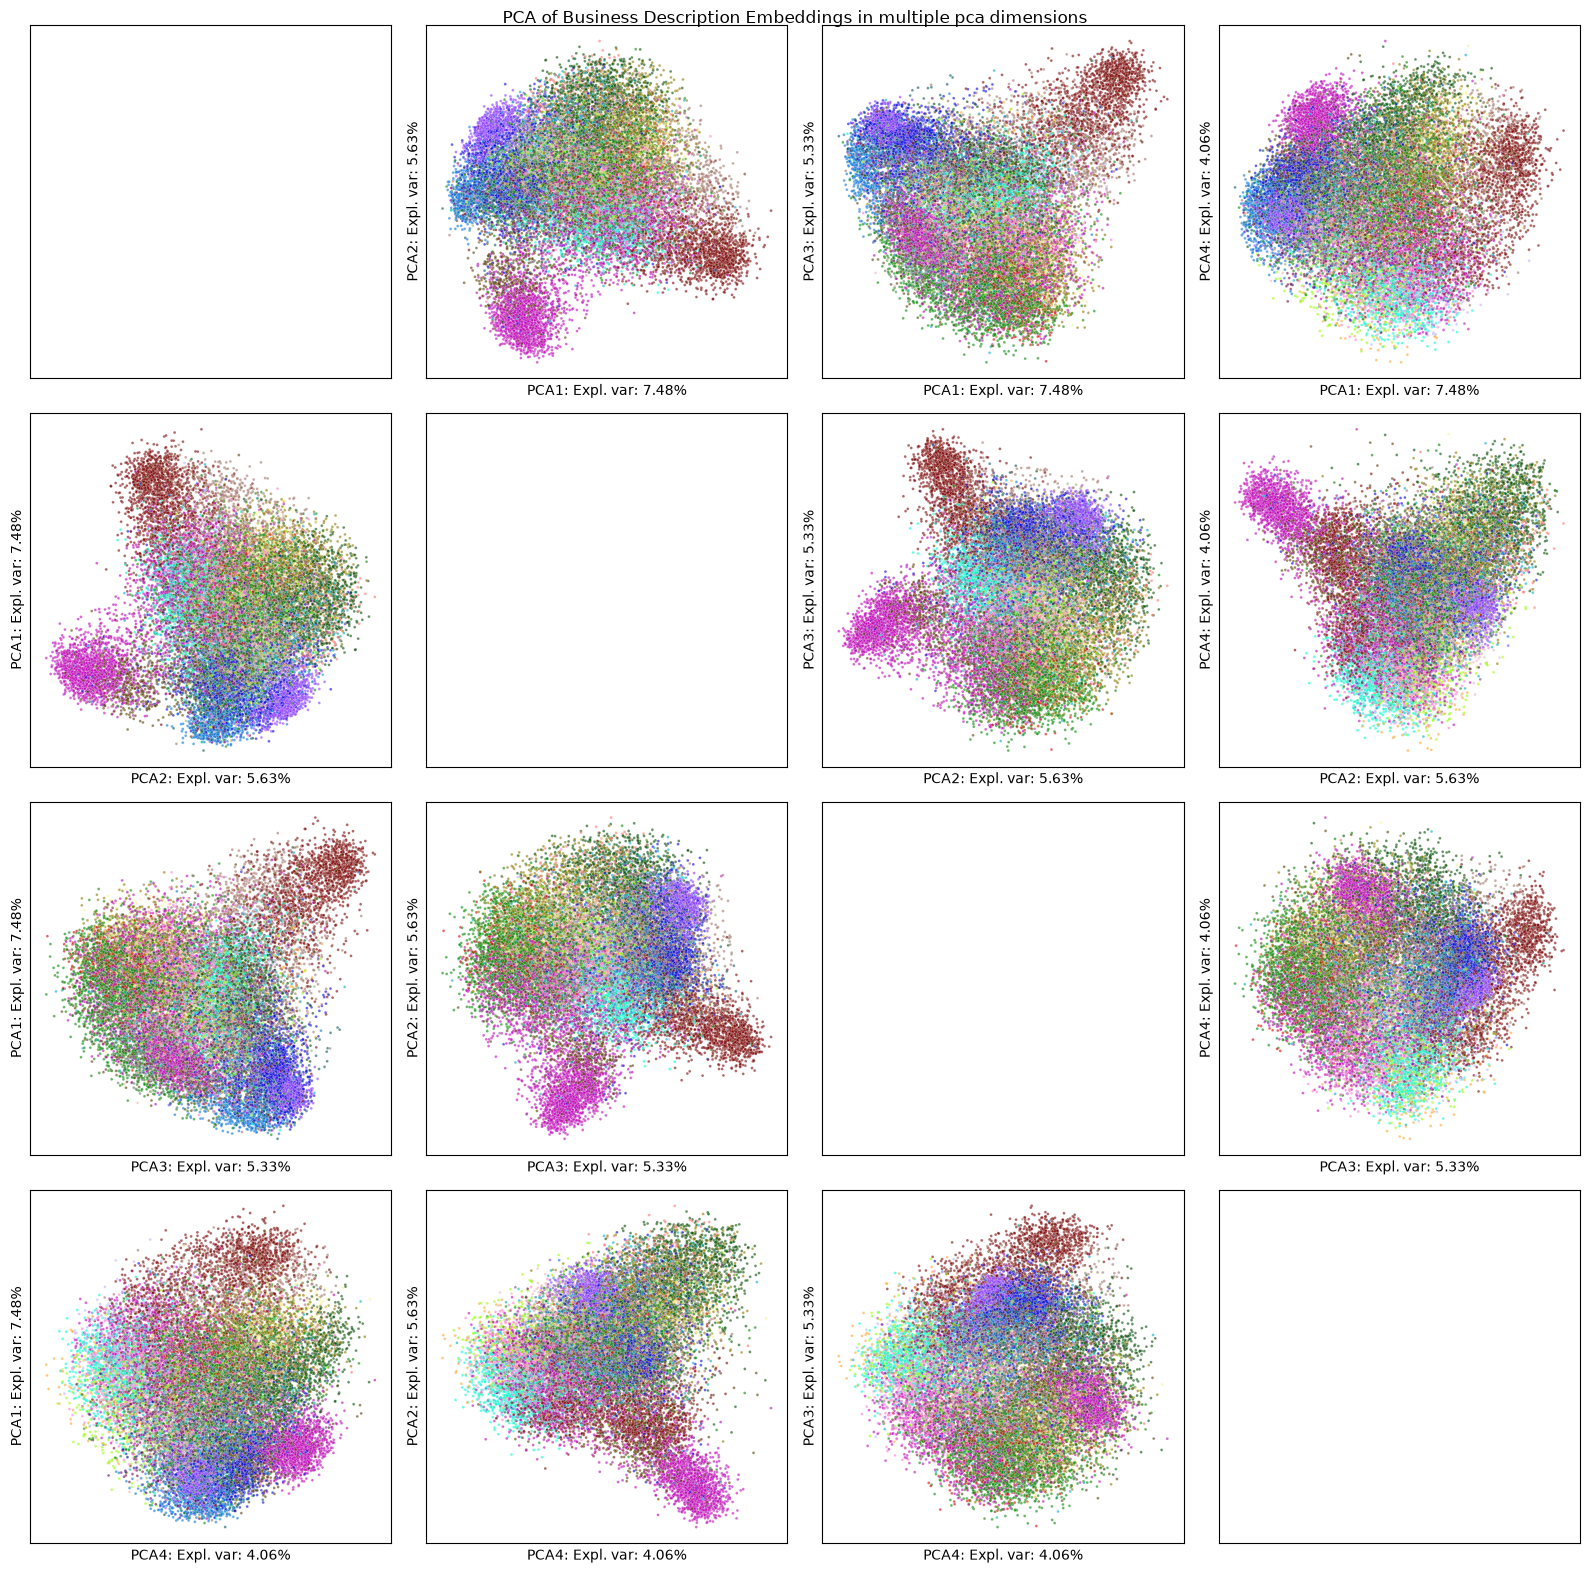

In [20]:
plot_explore_pca(X_train, y_train, first_n_components=4)

PCA plots also look way better and are not distorted anymore

# Fitting and comparing Classifier Models

### Tasks:
- Split the data into train and validation data
- Encode the industry labels using LabelEncoder (scikit-learn)
- Fit a LogisticRegression and a kNN-classifier
- Compare the model performance of both models:
    - Compute Accuracy and F1 score
        - Interpret the scores: Explain how they are computed and judge if your model performs well
        - Analyze the classification errors: 
            - Do the errors correlate with how well classes are represented?
            - Which industries does the model identify well and which seem to be similar?
    - Plot a confusion matrix for both models (combine scikit-learn confusion matrix and seaborn heatmap plot)
    - Do both models misclassify the same examples?

Import: Use proper axis labels for the plots! 

We have already loaded the data and split it into train and validation set. Afterwards the label have been encoded using the label encoder. We will now continnue with the fitting of LogisticRegression and kNN-classifiers.

#### Evaluation


In [21]:
def score_model(y_true, y_pred, print_results=True): 
    # Accuracy 
    accuracy =  accuracy_score(y_true, y_pred)
    # F1 score 
    f1_macro = f1_score(y_true, y_pred, average="macro")
    f1_micro = f1_score(y_true, y_pred, average="micro") 
    f1_weighted = f1_score(y_true, y_pred, average="weighted")
    
    scores = {
        "accuracy": accuracy,
        "f1_macro": f1_macro,
        "f1_micro": f1_micro,
        "f1_weighted": f1_weighted
    } 
    
    if print_results:
        print(f"Accuracy: {accuracy:.4f}")
        print(f"F1 macro: {f1_macro:.4f}")
        print(f"F1 micro: {f1_micro:.4f}")
        print(f"F1 weighted: {f1_weighted:.4f}")


    return scores 


**F1 Score (Binary)**
Harmonic mean of precision and recall. The model needs to achieve good precision and recall to receive a good F1 score, maximising one of them is not enough. It provides a good compromise when both are equally important. 
$$
F1_{binary} = \frac{2*TP}{2*TP+FP+FN}
$$

**F1 Score (Micro)**

F1 is usually a binary metric. It is extended to multiclass classification by performing some sort of aggregation or averaging. 
For the Micro F1. The total nr of true positives, false negatives and false positives are counted across all predictions.

Then the F1 Metric is calculated using these aggregated TP/FP/FN counts with the above formula.

**F1 Score (Macro)**

Calculate the F1 for each label separately. 
Get TP/FN/FN for each label, calculate its binary F1, then take the _unweighted_ average.
Does not take label imbalance into account. Every class is equally important.


**F1 Score (Weighted)**

Same as macro F1, but here the average is weighted by the support, which is the nr of true instances for each label (as seen in the ground truth labels y_true). Classes with higher support have more weight.

#### LogisticRegression

In [22]:
# Logistic Regression with default parameters
log_reg = LogisticRegression(max_iter=200).fit(X_train, y_train)
probs_log_reg = log_reg.predict_proba(X_val) #(n_samples, k_classes)
y_pred_log_reg = log_reg.classes_[np.argmax(probs_log_reg, axis=1)] #(n_samples,)
confidence_log_reg = np.max(probs_log_reg, axis=-1) #(n_samples,)

log_reg_scores = score_model(y_val, y_pred_log_reg)

Accuracy: 0.7391
F1 macro: 0.7134
F1 micro: 0.7391
F1 weighted: 0.7328


In [23]:
# Logistic Regression with class_weight="balanced"
# "Balanced" automatically sets the class weights inversely proportional to class frequencies
# Used when we care a lot about correctly identifying the minority classes.
# Penalizes mistakes on "rare" classes more.

# However, if the class distribution in the train set is representative of the true distribution, then this will hurt the model more. 
# We see that the F1 score is lower than the default logistic regression, because this weighting was done. 
# It would have helped, if we had an imbalanced train set, but a balanced test set.

log_reg_balanced = LogisticRegression(max_iter=200, class_weight="balanced").fit(X_train, y_train)
probs_balanced = log_reg_balanced.predict_proba(X_val) #(n_samples, k_classes)
y_pred_balanced = log_reg_balanced.classes_[np.argmax(probs_balanced, axis=1)] #(n_samples,)
confidence_balanced = np.max(probs_balanced, axis=-1) #(n_samples,) 

log_reg_balanced_scores = score_model(y_val, y_pred_balanced)



Accuracy: 0.7058
F1 macro: 0.6902
F1 micro: 0.7058
F1 weighted: 0.7050


#### K-NN Classifier

Getting the best _n\_neighbors_ value using the Elbow method

In [ ]:
def elbow_method_knn(X_train, y_train, X_val, y_val, plot=True):

    results = {
        "f1_macro": [],
        "f1_micro": [],
        "f1_weighted": [],
        "accuracy": []
    }
    k_values = list(range(1,30,2))
    for k in k_values:
        knn_classifier = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
        probs = knn_classifier.predict_proba(X_val)
        y_pred = knn_classifier.classes_[np.argmax(probs, axis=1)]
        confidence = np.max(probs, axis=-1)
        
        scores = score_model(y_val, y_pred, print_results=False)
        print(f"k: {k} accuracy: {scores["accuracy"]:.4f} f1_macro: {scores["f1_macro"]:.4f} f1_micro: {scores["f1_micro"]:.4f} f1_weighted: {scores["f1_weighted"]:.4f}")
        results["f1_macro"].append(scores["f1_macro"])
        results["f1_micro"].append(scores["f1_micro"])
        results["f1_weighted"].append(scores["f1_weighted"])
        results["accuracy"].append(scores["accuracy"])
        

    # best k for each metric 
    for key, value in results.items(): 
        print(f"Best k for {key}: {k_values[np.argmax(value)]}")


    if plot:
        # plot all metrics
        plt.figure(figsize=(10, 5))
        plt.plot(k_values, results["f1_macro"], label="F1 Macro")
        plt.plot(k_values, results["f1_micro"], label="F1 Micro")
        plt.plot(k_values, results["f1_weighted"], label="F1 Weighted")
        plt.plot(k_values, results["accuracy"], label="Accuracy")
        plt.title("Elbow method for KNN classifier")
        plt.xlabel("k")
        plt.ylabel("Score")
        plt.legend()
        plt.show()

k: 1 accuracy: 0.6647 f1_macro: 0.6356 f1_micro: 0.6647 f1_weighted: 0.6650
k: 3 accuracy: 0.6889 f1_macro: 0.6594 f1_micro: 0.6889 f1_weighted: 0.6876
k: 5 accuracy: 0.7182 f1_macro: 0.6983 f1_micro: 0.7182 f1_weighted: 0.7142
k: 7 accuracy: 0.7351 f1_macro: 0.7127 f1_micro: 0.7351 f1_weighted: 0.7298
k: 9 accuracy: 0.7314 f1_macro: 0.7122 f1_micro: 0.7314 f1_weighted: 0.7259
k: 11 accuracy: 0.7343 f1_macro: 0.7217 f1_micro: 0.7343 f1_weighted: 0.7294
k: 13 accuracy: 0.7288 f1_macro: 0.7112 f1_micro: 0.7288 f1_weighted: 0.7235
k: 15 accuracy: 0.7351 f1_macro: 0.7144 f1_micro: 0.7351 f1_weighted: 0.7293
k: 17 accuracy: 0.7336 f1_macro: 0.7116 f1_micro: 0.7336 f1_weighted: 0.7273
k: 19 accuracy: 0.7380 f1_macro: 0.7136 f1_micro: 0.7380 f1_weighted: 0.7313
k: 21 accuracy: 0.7332 f1_macro: 0.7103 f1_micro: 0.7332 f1_weighted: 0.7268
k: 23 accuracy: 0.7310 f1_macro: 0.7024 f1_micro: 0.7310 f1_weighted: 0.7244
k: 25 accuracy: 0.7292 f1_macro: 0.7041 f1_micro: 0.7292 f1_weighted: 0.7225
k: 2

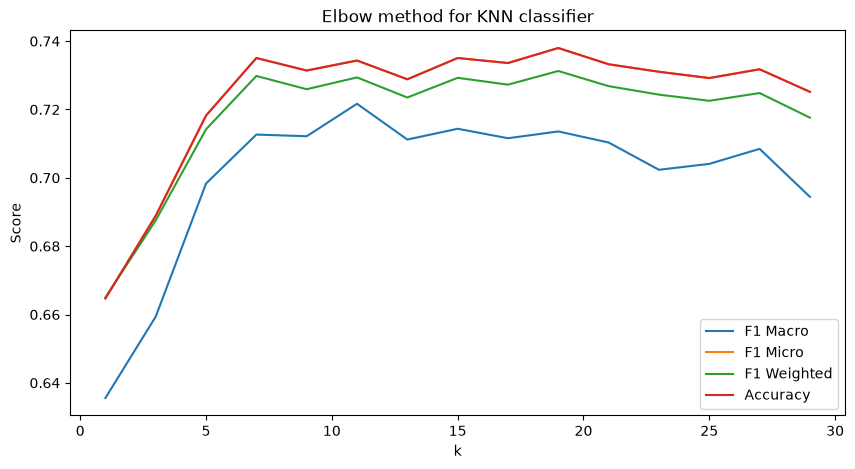

In [25]:
elbow_method_knn(X_train, y_train, X_val, y_val, plot=True)

k=19 looks like the sweet spot, though, macro f1 has a slightly higher peak at k=11.

Actually we can see here that in multi class classification, micro F1 is identical to accuracy. This does not hold for multi-label classification though. 

In [26]:
knn_classifier = KNeighborsClassifier(n_neighbors=19).fit(X_train, y_train) # get n with elbow method
probs_knn = knn_classifier.predict_proba(X_val)
y_pred_knn = knn_classifier.classes_[np.argmax(probs_knn, axis=1)]
confidence_knn = np.max(probs_knn, axis=-1)

knn_scores = score_model(y_val, y_pred_knn)

Accuracy: 0.7380
F1 macro: 0.7136
F1 micro: 0.7380
F1 weighted: 0.7313


In [27]:
# compare knn and logistic regression model 
def add_model_scores(df, model_scores, model_name): 
    model_scores.update({"model": model_name})
    df.loc[len(df)] = model_scores

df_model_comparison = pd.DataFrame(columns=["model", "accuracy", "f1_macro", "f1_micro", "f1_weighted"])

add_model_scores(df_model_comparison, log_reg_scores, "logistic regression")
add_model_scores(df_model_comparison, knn_scores, "k-nn")

df_model_comparison

,model,accuracy,f1_macro,f1_micro,f1_weighted
0,logistic regression,0.739099,0.713429,0.739099,0.732844
1,k-nn,0.737999,0.713578,0.737999,0.731264


From these aggregated metrics it looks like both models performances are very similar to each others. Logistic regression has slightly higher scores in all metrics.

However, the aggregated F1s might hide some differences, lets look at the binary f1 scrores

In [30]:
f1_scores_knn_per_class = f1_score(y_val, y_pred_knn, average=None)
f1_scores_log_reg_per_class = f1_score(y_val, y_pred_log_reg, average=None)

support_list = [(y_val == i).sum() / len(y_val) for i in range(n_industries)]


print("F1 scores per class:")
for i in range(len(f1_scores_knn_per_class)):
    support = (y_val == i).sum() / len(y_val)
    support_train = (y_train == i).sum() / len(y_train)
    print(f"Class {i:2d}: KNN: {f1_scores_knn_per_class[i]:.4f} LogReg: {f1_scores_log_reg_per_class[i]:.4f} Support val: {support*100:.2f}% Support train: {support_train*100:.2f}%")


F1 scores per class:
Class  0: KNN: 0.8397 LogReg: 0.7903 Support val: 2.27% Support train: 2.31%
Class  1: KNN: 0.8812 LogReg: 0.9263 Support val: 3.48% Support train: 3.49%
Class  2: KNN: 0.7022 LogReg: 0.7031 Support val: 11.47% Support train: 11.52%
Class  3: KNN: 0.3208 LogReg: 0.3571 Support val: 2.93% Support train: 2.96%
Class  4: KNN: 0.5039 LogReg: 0.5138 Support val: 2.42% Support train: 2.43%
Class  5: KNN: 0.6944 LogReg: 0.6897 Support val: 4.21% Support train: 4.29%
Class  6: KNN: 0.7752 LogReg: 0.7883 Support val: 2.46% Support train: 2.48%
Class  7: KNN: 0.5806 LogReg: 0.4667 Support val: 0.66% Support train: 0.66%
Class  8: KNN: 0.6695 LogReg: 0.6753 Support val: 4.87% Support train: 4.85%
Class  9: KNN: 0.7529 LogReg: 0.7816 Support val: 1.58% Support train: 1.55%
Class 10: KNN: 0.6883 LogReg: 0.7102 Support val: 7.07% Support train: 6.94%
Class 11: KNN: 0.8444 LogReg: 0.8214 Support val: 3.99% Support train: 4.04%
Class 12: KNN: 0.7887 LogReg: 0.7729 Support val: 3.7

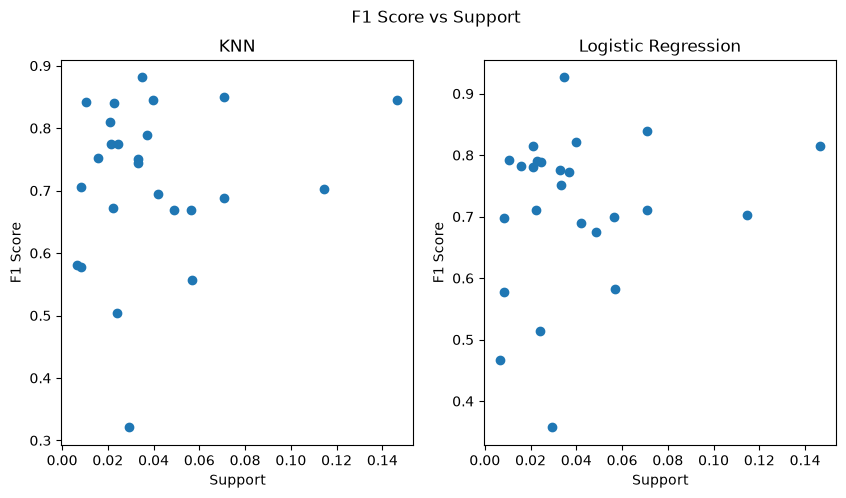

In [36]:
# plot class support vs f1 score
plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
plt.title("KNN")
plt.scatter(support_list, f1_scores_knn_per_class, label="F1 KNN")
plt.xlabel("Support")
plt.ylabel("F1 Score")
plt.subplot(1,2,2)
plt.title("Logistic Regression")
plt.scatter(support_list, f1_scores_log_reg_per_class, label="F1 LogReg")
plt.xlabel("Support")
plt.ylabel("F1 Score")
plt.suptitle("F1 Score vs Support")
plt.show()


There does not seem to be a clear correlation between the support of a class and the models f1 score for that class.

In [37]:
corr_support_f1_knn = np.corrcoef(support_list, f1_scores_knn_per_class)
corr_support_f1_log_reg = np.corrcoef(support_list, f1_scores_log_reg_per_class)

print(f"Correlation support F1 KNN: {corr_support_f1_knn[0,1]:.4f}")
print(f"Correlation support F1 Logistic Regression: {corr_support_f1_log_reg[0,1]:.4f}")


Correlation support F1 KNN: 0.1719
Correlation support F1 Logistic Regression: 0.1913


Correlation between nr of samples in a class and the models f1 score on that class is weak for both models $r<0.2$.

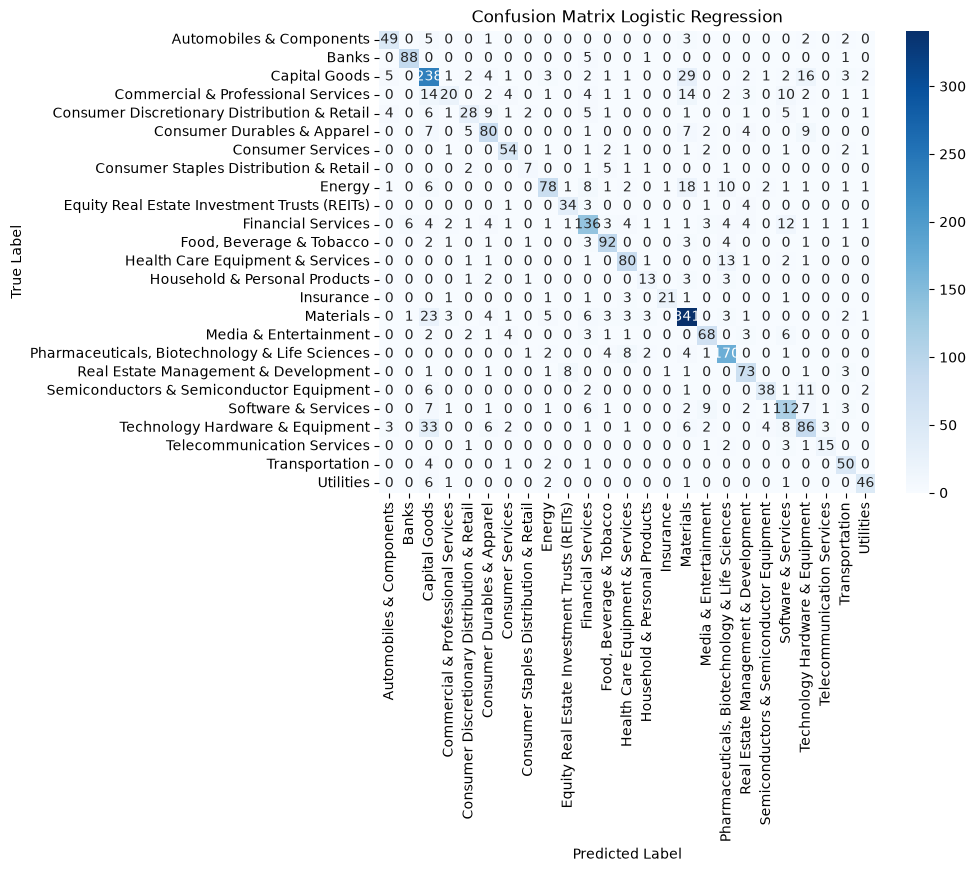

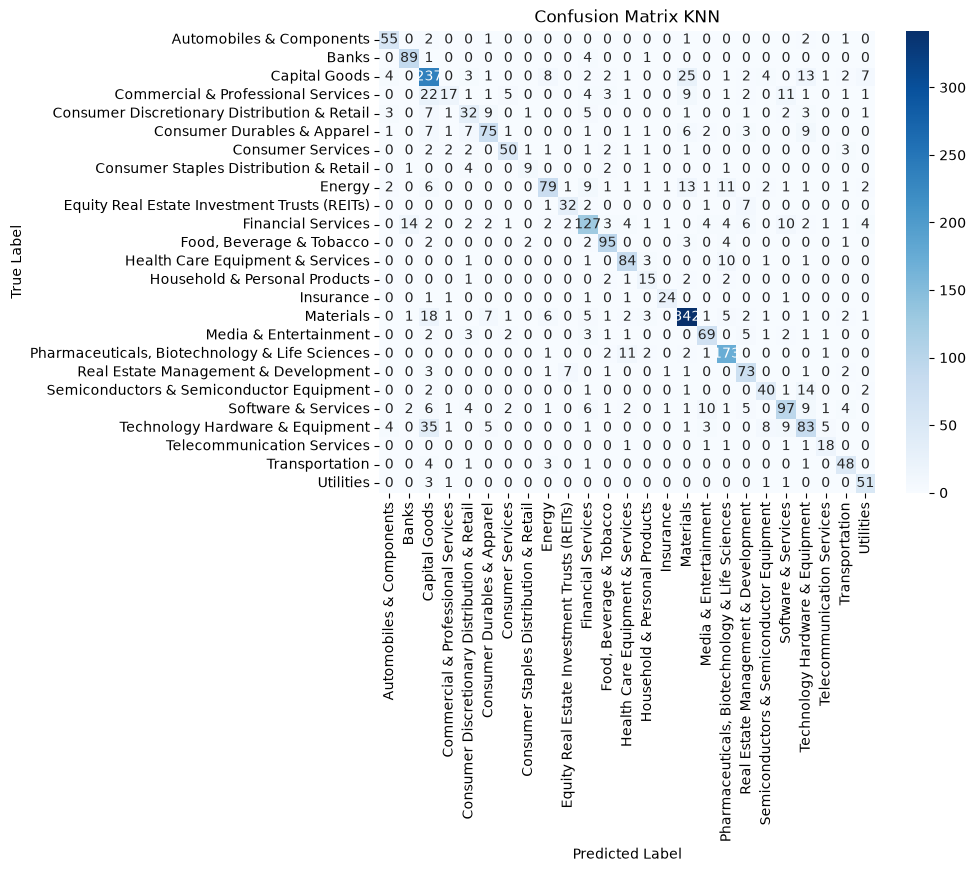

In [61]:
# i would like to plot the confusion matrices
conf_matrix_knn = confusion_matrix(y_val, y_pred_knn)
conf_matrix_log_reg = confusion_matrix(y_val, y_pred_log_reg)

# plot confusion matrix
plt.figure(figsize=(8, 6))
plt.title("Logistic Regression")
sns.heatmap(
    conf_matrix_log_reg,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.inverse_transform(log_reg.classes_),
    yticklabels=label_encoder.inverse_transform(log_reg.classes_)
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Logistic Regression")
plt.show()


plt.figure(figsize=(8, 6))
plt.title("KNN")
sns.heatmap(
    conf_matrix_knn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.inverse_transform(knn_classifier.classes_),
    yticklabels=label_encoder.inverse_transform(knn_classifier.classes_)
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix KNN")
plt.show()

In [60]:
def get_top_misclassifications_by_percentage(conf_matrix, class_names, top_n=5):
    """
    Find the top_n most frequent misclassifications by percentage (off-diagonal).
    Returns a DataFrame with the true class, predicted class, count, and percentage of misclassification for that true class.
    """
    miscls = []
    for i, true_class in enumerate(class_names):
        row = conf_matrix[i].copy()
        n_total = row.sum()
        row[i] = 0  # ignore correct predictions
        for j, count in enumerate(row):
            if count > 0:
                percent = count / n_total if n_total > 0 else 0
                miscls.append({
                    "True Class": true_class,
                    "Predicted as": class_names[j],
                    "Count": count,
                    "Percent": percent
                })
    df = pd.DataFrame(miscls)
    if not df.empty:
        df = df.sort_values(by="Percent", ascending=False).head(top_n)
    return df

class_names_knn = label_encoder.inverse_transform(knn_classifier.classes_)
class_names_log_reg = label_encoder.inverse_transform(log_reg.classes_)
top_n = 8

print("\nTop 5 Misclassifications by Percentage in Logistic Regression Classifier:")
top_misc_log = get_top_misclassifications_by_percentage(conf_matrix_log_reg, class_names_log_reg, top_n=top_n)
display(top_misc_log)


print("Top 5 Misclassifications by Percentage in KNN Classifier:")
top_misc_knn = get_top_misclassifications_by_percentage(conf_matrix_knn, class_names_knn, top_n=top_n)
display(top_misc_knn)




Top 5 Misclassifications by Percentage in Logistic Regression Classifier:


,True Class,Predicted as,Count,Percent
70,Consumer Staples Distribution & Retail,"Food, Beverage & Tobacco",5,0.277778
201,Technology Hardware & Equipment,Capital Goods,33,0.212903
185,Semiconductors & Semiconductor Equipment,Technology Hardware & Equipment,11,0.180328
24,Commercial & Professional Services,Capital Goods,14,0.175000
31,Commercial & Professional Services,Materials,14,0.175000
41,Consumer Discretionary Distribution & Retail,Consumer Durables & Apparel,9,0.136364
81,Energy,Materials,18,0.135338
135,Household & Personal Products,"Pharmaceuticals, Biotechnology & Life Sciences",3,0.130435


Top 5 Misclassifications by Percentage in KNN Classifier:


,True Class,Predicted as,Count,Percent
23,Commercial & Professional Services,Capital Goods,22,0.275000
184,Semiconductors & Semiconductor Equipment,Technology Hardware & Equipment,14,0.229508
204,Technology Hardware & Equipment,Capital Goods,35,0.225806
72,Consumer Staples Distribution & Retail,Consumer Discretionary Distribution & Retail,4,0.222222
95,Equity Real Estate Investment Trusts (REITs),Real Estate Management & Development,7,0.162791
33,Commercial & Professional Services,Software & Services,11,0.137500
40,Consumer Discretionary Distribution & Retail,Consumer Durables & Apparel,9,0.136364
30,Commercial & Professional Services,Materials,9,0.112500


There are a few classes that the model has problems classifying correctly.

There is a lot of confusion for the classes: Consumer Staples Distribution & Retail, Commercial & Professional Services, Semiconductor & Semiconductor Equipment, Technology Hardware & Equipment.

Most of the misclassifications seem between classes that are pretty simmilar to each other.  

Both models make the same errors. E.g. both misclassify a lot of Commercial & Professional Services with Capital Goods.

# Optional: Confidence Weighted Prediction

## Deliverables:

- Provide a notebook with the implementation and training of an industry classifier model
- The model shall output the industry classification and its confidence as a tuple of vectors $(\hat{y}_{pred}, \hat{y}_{confidence})$
- The confidence score must be between 0 and 1, $\hat{y}_{confidence} [i] \in [0,1]$
- Your model will be evaluated on a private test set
- Designing the confidence score is your task. You may use p-values, a voting mechanism of multiple models, or other techniques
- Another option is to add more features, e.g. financial data, to X

## Scoring

Your submission is scored with the function `confidence_score` below:

$$\text{score} = F_1^{\text{weighted}}(y, \hat{y}_{pred}) \cdot \left(1 - \text{Brier}\right), \qquad \text{Brier} = \frac{1}{n}\sum_{i=1}^{n} \left(\hat{y}_{confidence}[i] - \mathbb{1}[\hat{y}_{pred}[i] = y_i]\right)^2$$

- **Weighted F1** measures how good your predicted industries are (the confidence does not enter here).
- **Brier score** measures how good your confidence is: $\hat{y}_{confidence}[i]$ should be the probability that prediction $i$ is correct.
- The Brier term is smallest when your confidence is *calibrated*: among all predictions with confidence 0.8, about 80% should be correct.
- Always reporting confidence 1.0 does not pay off (every wrong prediction costs the maximum penalty), and neither does reporting very low confidence everywhere.

In [ ]:
from sklearn.metrics import f1_score


def confidence_score(y_true, y_pred, confidence):
    """
    Score for the confidence weighted prediction task.

    Parameters:
    -----------
    y_true : array-like
        True class labels
    y_pred : array-like
        Predicted class labels
    confidence : array-like
        Confidence for each prediction, in [0, 1]
        (= estimated probability that the prediction is correct)

    Returns:
    --------
    float
        weighted F1 * (1 - Brier score), between 0 and 1 (higher is better)
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    confidence = np.asarray(confidence, dtype=float)

    assert len(y_true) == len(y_pred) == len(confidence), "Inputs must have the same length"
    assert np.all((confidence >= 0) & (confidence <= 1)), "Confidence must be between 0 and 1"

    f1 = f1_score(y_true, y_pred, average="weighted")
    correct = (y_true == y_pred).astype(float)
    brier = np.mean((confidence - correct) ** 2)

    return f1 * (1 - brier)

In [ ]:
# Example: evaluate a model on the validation set
# (requires y_train and y_val from the label encoding task)

example_model = LogisticRegression(max_iter=1000).fit(X_train, y_train)

y_proba = example_model.predict_proba(X_val)
y_pred = example_model.classes_[np.argmax(y_proba, axis=1)]
confidence = np.max(y_proba, axis=1)  # probability of the predicted class

print("Score with model confidence:  {:.4f}".format(confidence_score(y_val, y_pred, confidence)))
print("Score with confidence = 1.0:  {:.4f}".format(confidence_score(y_val, y_pred, np.ones(len(y_pred)))))